# 🤖 Step 3 — Model Training

**เป้าหมาย:** เทรนโมเดล 2 ตัวแล้วเปรียบเทียบประสิทธิภาพ

| โมเดล | บทบาท | เหมาะกับ |
|---|---|---|
| **Logistic Regression** | Baseline | เริ่มต้น ตีความง่าย |
| **LightGBM** | Main model | ข้อมูลขนาดใหญ่ ล้านแถว |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. โหลดข้อมูลจาก Step 2

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print(f"Train: {X_train.shape[0]} แถว | Test: {X_test.shape[0]} แถว")
X_train.head(3)

Train: 614 แถว | Test: 154 แถว


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age
0,0.559899,1.242116,-0.379915,-0.252550,-0.342139,1.772751,-0.088592,-0.652557
1,-1.117067,0.877809,-0.379915,-1.890261,-0.796400,-0.311600,-0.838754,-0.442837
2,0.559899,2.566866,-1.266864,0.523209,-0.830469,-0.391256,0.149105,-0.023397


## 3. โมเดลที่ 1 — Logistic Regression (Baseline)

> **ทำงานอย่างไร?**  
> คำนวณ "น้ำหนัก" ให้แต่ละ feature แล้วรวมกัน  
> `P(เบาหวาน) = sigmoid( w₁×Glucose + w₂×BMI + ... + b )`  
> sigmoid แปลงตัวเลขใดก็ได้ → ค่าระหว่าง 0–1 (ความน่าจะเป็น)

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {acc_lr:.4f}  ({acc_lr*100:.1f}%)")
print(f"AUC-ROC  : {auc_lr:.4f}")

Accuracy : 0.8247  (82.5%)
AUC-ROC  : 0.8789


### 📊 Metrics คืออะไร?

```
                  ทายว่า 'ไม่เป็น'   ทายว่า 'เป็น'
จริงๆ 'ไม่เป็น'       TN              FP  ← alarm เกิน
จริงๆ 'เป็น'          FN              TP
                        ↑
                   พลาดคนไข้! (อันตรายมาก)
```

- **Precision** = TP / (TP+FP) → ที่ทายว่าเป็น ถูกกี่ %  
- **Recall** = TP / (TP+FN) → คนเป็นจริง จับได้กี่ % ← **สำคัญสุดในทางการแพทย์**  
- **AUC-ROC** → 0.5 = เดาสุ่ม, 1.0 = สมบูรณ์แบบ

In [4]:
print("Classification Report — Logistic Regression:")
print(classification_report(y_test, y_pred_lr,
      target_names=["No Diabetes", "Diabetes"]))

Classification Report — Logistic Regression:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.89      0.87       100
    Diabetes       0.78      0.70      0.74        54

    accuracy                           0.82       154
   macro avg       0.81      0.80      0.80       154
weighted avg       0.82      0.82      0.82       154



## 4. โมเดลที่ 2 — LightGBM

> **ทำงานอย่างไร? (Gradient Boosting)**  
> รอบที่ 1: สร้าง decision tree ต้นแรก → ทายผิดหลายแถว  
> รอบที่ 2: ต้นที่ 2 แก้ข้อผิดพลาดของต้นแรก  
> รอบที่ 3: ต้นที่ 3 แก้ข้อผิดพลาดที่เหลือ ...  
> ทำซ้ำ `n_estimators` ครั้ง แล้วรวมผลทุกต้น

> **scale_pos_weight** = neg/pos → บอก LightGBM ว่า class เบาหวานหายากกว่า ให้ความสำคัญมากขึ้น

In [5]:
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

print(f"Negative (ไม่เป็น): {neg}")
print(f"Positive (เป็น)   : {pos}")
print(f"scale_pos_weight  : {scale:.2f}  → LightGBM จะให้น้ำหนัก class เบาหวาน {scale:.2f}× มากขึ้น")

Negative (ไม่เป็น): 399
Positive (เป็น)   : 215
scale_pos_weight  : 1.86  → LightGBM จะให้น้ำหนัก class เบาหวาน 1.86× มากขึ้น


In [6]:
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print(f"Accuracy : {acc_lgbm:.4f}  ({acc_lgbm*100:.1f}%)")
print(f"AUC-ROC  : {auc_lgbm:.4f}")

Accuracy : 0.8961  (89.6%)
AUC-ROC  : 0.9680


In [7]:
print("Classification Report — LightGBM:")
print(classification_report(y_test, y_pred_lgbm,
      target_names=["No Diabetes", "Diabetes"]))

Classification Report — LightGBM:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.89      0.92       100
    Diabetes       0.82      0.91      0.86        54

    accuracy                           0.90       154
   macro avg       0.88      0.90      0.89       154
weighted avg       0.90      0.90      0.90       154



## 5. สรุปเปรียบเทียบ

In [8]:
results = pd.DataFrame({
    "Model":    ["Logistic Regression", "LightGBM"],
    "Accuracy": [round(acc_lr, 4),      round(acc_lgbm, 4)],
    "AUC-ROC": [round(auc_lr, 4),       round(auc_lgbm, 4)],
})
results.set_index("Model")

,Accuracy,AUC-ROC
Model,,
Logistic Regression,0.8247,0.8789
LightGBM,0.8961,0.9680


## 6. Visualization — ROC Curve, Feature Importance, Confusion Matrix

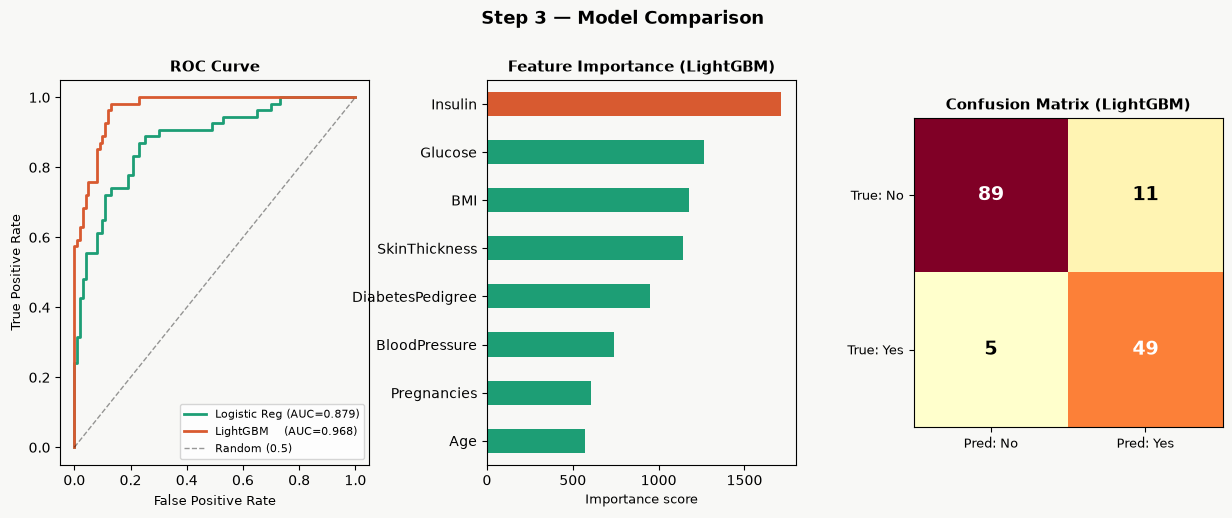

Saved: step3_results.png


In [9]:
fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor("#F8F8F6")
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ROC Curve
ax1 = fig.add_subplot(gs[0])
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
ax1.plot(fpr_lr,   tpr_lr,   color="#1D9E75", lw=2,
         label=f"Logistic Reg (AUC={auc_lr:.3f})")
ax1.plot(fpr_lgbm, tpr_lgbm, color="#D85A30", lw=2,
         label=f"LightGBM    (AUC={auc_lgbm:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (0.5)")
ax1.set_xlabel("False Positive Rate", fontsize=9)
ax1.set_ylabel("True Positive Rate",  fontsize=9)
ax1.set_title("ROC Curve", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_facecolor("#F8F8F6")

# Feature Importance
ax2 = fig.add_subplot(gs[1])
importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values()
colors_bar = ["#D85A30" if v == importance.max() else "#1D9E75" for v in importance.values]
importance.plot(kind="barh", ax=ax2, color=colors_bar)
ax2.set_title("Feature Importance (LightGBM)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Importance score", fontsize=9)
ax2.set_facecolor("#F8F8F6")

# Confusion Matrix
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test, y_pred_lgbm)
ax3.imshow(cm, cmap="YlOrRd")
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(["Pred: No", "Pred: Yes"], fontsize=9)
ax3.set_yticklabels(["True: No", "True: Yes"], fontsize=9)
ax3.set_title("Confusion Matrix (LightGBM)", fontsize=11, fontweight="bold")
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i, j]), ha="center", va="center",
                 fontsize=14, fontweight="bold",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.suptitle("Step 3 — Model Comparison", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("step3_results.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: step3_results.png")

## ✅ สรุป Step 3

| | Logistic Regression | LightGBM |
|---|---|---|
| Accuracy | ~82.5% | **~89.6%** |
| AUC-ROC | ~0.879 | **~0.968** |
| Recall (เบาหวาน) | ~70% | **~91%** |

**LightGBM ชนะทุก metric** โดยเฉพาะ Recall ที่สำคัญมากสำหรับงานทางการแพทย์

---
➡️ **Step ถัดไป → Step 4: Threshold Tuning** — ปรับจุดตัดจาก 0.5 เพื่อให้จับคนไข้เบาหวานได้มากขึ้น